# Polygon Audit — KML Inventory F25-04

**Purpose:** Read-only reconnaissance of every KML/KMZ file under `~/berkeley-data/docs/kml_versions/` to find polygons damaged by iPad editing (excessive vertex counts) and identify which projects have multiple polygon versions floating around.

**This notebook does not modify any files.** It produces:
- A pandas DataFrame inventory of every polygon found
- A CSV report saved to disk
- Visualizations of vertex-count distribution
- A duplicate-detection report (which projects appear in multiple files)

Run cells one at a time. Each cell is independent enough that you can pause and inspect the output before continuing.

---

**Conventions used:**
- KML namespace: `http://www.opengis.net/kml/2.2`
- Google extensions namespace: `http://www.google.com/kml/ext/2.2` (for `gx:` elements like tours)
- Polygons live at `Placemark/Polygon/outerBoundaryIs/LinearRing/coordinates`
- Each coordinate tuple is `lon,lat[,alt]` — note the lon-before-lat order, opposite of most conventions

In [1]:
! pip install lxml shapely pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 9.3 MB/s  0:00:00m 9.7 MB/s eta 0:00:01m


## Cell 1 — Imports and configuration

In [2]:
import os
import zipfile
from pathlib import Path
from datetime import datetime
from collections import Counter

from lxml import etree
import pandas as pd
from shapely.geometry import Polygon
from shapely.errors import GEOSException
import matplotlib.pyplot as plt

# --- Paths ---
KML_DIR = Path('/Users/johngage/berkeley-data/docs/kml_versions')
OUTPUT_DIR = Path('/Users/johngage/berkeley-data/notebooks/06_polygon_cleanup/reports')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- KML namespaces ---
NS = {
    'kml': 'http://www.opengis.net/kml/2.2',
    'gx': 'http://www.google.com/kml/ext/2.2',
}

# --- Thresholds for flagging ---
VERTEX_FLAG_THRESHOLD = 10  # any polygon with more vertices than this gets flagged

print(f'KML directory: {KML_DIR}')
print(f'Exists: {KML_DIR.exists()}')
print(f'Output directory: {OUTPUT_DIR}')

KML directory: /Users/johngage/berkeley-data/docs/kml_versions
Exists: True
Output directory: /Users/johngage/berkeley-data/notebooks/06_polygon_cleanup/reports


## Cell 2 — Inventory the directory

First sanity check: what files are actually here? List every `.kml` and `.kmz` with size and modification time, sorted by mtime. The oldest files are most likely your pre-iPad versions.

In [11]:
kml_files = sorted(
    [p for p in KML_DIR.rglob('*') if p.suffix.lower() in ('.kml', '.kmz')],
    key=lambda p: p.stat().st_mtime
)

files_df = pd.DataFrame([
    {
        'path': str(p.relative_to(KML_DIR)),
        'size_kb': round(p.stat().st_size / 1024, 1),
        'mtime': datetime.fromtimestamp(p.stat().st_mtime).strftime('%Y-%m-%d %H:%M'),
        'extension': p.suffix.lower(),
        'full_path': str(p),
    }
    for p in kml_files
])

print(f'Found {len(files_df)} KML/KMZ files')
print(f'Total size: {files_df["size_kb"].sum():,.1f} KB')
print(f'Date range: {files_df["mtime"].min()} → {files_df["mtime"].max()}')
files_df

Found 16 KML/KMZ files
Total size: 950.8 KB
Date range: 2026-04-14 17:45 → 2026-04-25 09:00


,path,size_kb,mtime,extension,full_path
0,berkeley_skyline_v5_20260414_1558.kml,144.2,2026-04-14 17:45,.kml,/Users/johngage/berkeley-data/docs/kml_version...
1,haste_corrected.kml.kmz,0.8,2026-04-14 17:45,.kmz,/Users/johngage/berkeley-data/docs/kml_version...
2,haste_corrected.kmz,0.8,2026-04-14 17:45,.kmz,/Users/johngage/berkeley-data/docs/kml_version...
3,haste_extracted/doc.kml,1.7,2026-04-14 17:45,.kml,/Users/johngage/berkeley-data/docs/kml_version...
4,Berkeley Housing Pipeline - 3D Skyline.kml,128.6,2026-04-19 17:09,.kml,/Users/johngage/berkeley-data/docs/kml_version...
5,205sec.kml,7.2,2026-04-23 12:53,.kml,/Users/johngage/berkeley-data/docs/kml_version...
6,berkeley-housing-pipeline-tour-45sec.kml,5.8,2026-04-23 12:53,.kml,/Users/johngage/berkeley-data/docs/kml_version...
7,berkeley-overview-tour.kml,3.1,2026-04-23 12:53,.kml,/Users/johngage/berkeley-data/docs/kml_version...
8,berkeley-tour-45sec-rebuilt.kml,3.9,2026-04-23 12:53,.kml,/Users/johngage/berkeley-data/docs/kml_version...
9,berkeley-tour-extended-dramatic.kml,5.5,2026-04-23 12:53,.kml,/Users/johngage/berkeley-data/docs/kml_version...


## Cell 3 — Peek at one file's structure

Before processing all of them, parse one and look at what's inside. This confirms the schema assumptions (namespaces, where polygons live, whether ExtendedData is used for project IDs) before we trust the bulk loop.

If this cell errors or shows unexpected structure, **stop and tell me** — the assumptions in Cell 4 may need adjusting.

In [12]:
def load_kml_root(path: Path) -> etree._Element:
    """Load a KML or KMZ file and return the parsed root element."""
    if path.suffix.lower() == '.kmz':
        with zipfile.ZipFile(path) as z:
            # KMZ convention: the main KML is doc.kml, but be tolerant
            kml_names = [n for n in z.namelist() if n.lower().endswith('.kml')]
            if not kml_names:
                raise ValueError(f'No .kml inside KMZ: {path}')
            main = 'doc.kml' if 'doc.kml' in kml_names else kml_names[0]
            with z.open(main) as f:
                return etree.parse(f).getroot()
    else:
        return etree.parse(str(path)).getroot()

# Pick the first file to peek at — change index if you want a different one
if len(files_df) == 0:
    raise RuntimeError('No KML files found. Check KML_DIR.')

sample_path = Path(files_df.iloc[0]['full_path'])
print(f'Inspecting: {sample_path.name}\n')

root = load_kml_root(sample_path)
print(f'Root tag: {root.tag}')
print(f'Declared namespaces: {root.nsmap}\n')

placemarks = root.findall('.//kml:Placemark', NS)
polygons = root.findall('.//kml:Polygon', NS)
print(f'Placemarks: {len(placemarks)}')
print(f'Polygons: {len(polygons)}')

# Show the first placemark's structure to see what fields are available
if placemarks:
    first = placemarks[0]
    print(f'\n--- First placemark structure ---')
    name = first.findtext('kml:name', namespaces=NS)
    print(f'Name: {name}')
    
    # ExtendedData (where project_id should live if our exporter is well-designed)
    ext_data = first.find('kml:ExtendedData', NS)
    if ext_data is not None:
        print('ExtendedData fields:')
        for data in ext_data.findall('kml:Data', NS):
            key = data.get('name')
            val = data.findtext('kml:value', namespaces=NS)
            print(f'  {key}: {val}')
    else:
        print('No ExtendedData (no project_id round-trip yet)')
    
    # Polygon details
    poly = first.find('.//kml:Polygon', NS)
    if poly is not None:
        extrude = poly.findtext('kml:extrude', namespaces=NS)
        alt_mode = poly.findtext('kml:altitudeMode', namespaces=NS)
        print(f'Extrude: {extrude}, altitudeMode: {alt_mode}')

Inspecting: berkeley_skyline_v5_20260414_1558.kml

Root tag: {http://www.opengis.net/kml/2.2}kml
Declared namespaces: {None: 'http://www.opengis.net/kml/2.2'}

Placemarks: 165
Polygons: 165

--- First placemark structure ---
Name: 2400 BOWDITCH St
No ExtendedData (no project_id round-trip yet)
Extrude: 1, altitudeMode: relativeToGround


## Cell 4 — Main inventory loop

Walk every file, every placemark, every polygon. Build one row per polygon with all the fields we'll want for diagnosis. This is the slow cell on first run; subsequent cells operate on the resulting DataFrame.

In [13]:
def parse_coords(coords_text: str) -> list[tuple[float, float, float]]:
    """Parse a KML <coordinates> text block into a list of (lon, lat, alt) tuples.
    
    KML coordinates are space- or whitespace-separated tuples of comma-separated
    lon,lat[,alt] values. The order is lon,lat — opposite of most conventions.
    Altitude is optional; we default to 0.0 when absent.
    """
    if not coords_text:
        return []
    coords = []
    for token in coords_text.split():
        parts = token.split(',')
        if len(parts) >= 2:
            lon = float(parts[0])
            lat = float(parts[1])
            alt = float(parts[2]) if len(parts) >= 3 else 0.0
            coords.append((lon, lat, alt))
    return coords

def extract_extended_data(placemark: etree._Element) -> dict:
    """Pull ExtendedData fields into a dict."""
    out = {}
    ext = placemark.find('kml:ExtendedData', NS)
    if ext is None:
        return out
    for data in ext.findall('kml:Data', NS):
        key = data.get('name')
        val = data.findtext('kml:value', namespaces=NS)
        if key:
            out[key] = val
    return out

def polygon_area_sqm(coords: list[tuple[float, float, float]]) -> float:
    """Approximate polygon area in square meters using shapely + an equal-area projection trick.
    
    For Berkeley-scale polygons this is good enough: we treat 1 degree of longitude
    at latitude L as cos(L) * 111320 meters. Latitude is roughly 111320 m/deg everywhere.
    Not for cartographic publication — just for relative size comparison.
    """
    import math
    if len(coords) < 3:
        return 0.0
    mean_lat = sum(c[1] for c in coords) / len(coords)
    lon_m = math.cos(math.radians(mean_lat)) * 111_320
    lat_m = 111_320
    xy = [(c[0] * lon_m, c[1] * lat_m) for c in coords]
    try:
        return abs(Polygon(xy).area)
    except (GEOSException, ValueError):
        return 0.0

rows = []
errors = []

for _, file_row in files_df.iterrows():
    fpath = Path(file_row['full_path'])
    try:
        root = load_kml_root(fpath)
    except Exception as e:
        errors.append({'file': file_row['path'], 'error': f'parse: {e}'})
        continue

    placemarks = root.findall('.//kml:Placemark', NS)
    for pm_idx, pm in enumerate(placemarks):
        pm_name = pm.findtext('kml:name', namespaces=NS) or '(unnamed)'
        pm_id = pm.get('id')
        ext_data = extract_extended_data(pm)
        project_id = ext_data.get('project_id') or ext_data.get('id') or pm_id

        # A placemark may have one Polygon or several inside MultiGeometry
        polygons = pm.findall('.//kml:Polygon', NS)
        if not polygons:
            continue

        for poly_idx, poly in enumerate(polygons):
            coord_el = poly.find('.//kml:outerBoundaryIs/kml:LinearRing/kml:coordinates', NS)
            if coord_el is None or not coord_el.text:
                continue
            coords = parse_coords(coord_el.text)
            # KML rings repeat the first point as the last; subtract 1 for true vertex count
            vertex_count = max(0, len(coords) - 1)
            altitudes = [c[2] for c in coords]
            has_altitude = any(a != 0 for a in altitudes)
            extrude_text = poly.findtext('kml:extrude', namespaces=NS)
            extruded = extrude_text == '1'

            rows.append({
                'file': file_row['path'],
                'file_mtime': file_row['mtime'],
                'placemark_idx': pm_idx,
                'polygon_idx': poly_idx,
                'placemark_name': pm_name,
                'placemark_id': pm_id,
                'project_id': project_id,
                'vertex_count': vertex_count,
                'area_sqm': round(polygon_area_sqm(coords), 1),
                'extruded': extruded,
                'has_altitude': has_altitude,
                'max_altitude': round(max(altitudes), 2) if altitudes else 0,
                'has_ext_data': len(ext_data) > 0,
                'ext_data_keys': ','.join(sorted(ext_data.keys())) if ext_data else '',
            })

inv = pd.DataFrame(rows)
print(f'Parsed {len(inv)} polygons across {inv["file"].nunique()} files')
print(f'Errors: {len(errors)}')
if errors:
    print(pd.DataFrame(errors))
inv.head(10)

Parsed 828 polygons across 7 files
Errors: 0


,file,file_mtime,placemark_idx,polygon_idx,placemark_name,placemark_id,project_id,vertex_count,area_sqm,extruded,has_altitude,max_altitude,has_ext_data,ext_data_keys
0,berkeley_skyline_v5_20260414_1558.kml,2026-04-14 17:45,0,0,2400 BOWDITCH St,None,None,4,3424.0,True,True,85.3,False,
1,berkeley_skyline_v5_20260414_1558.kml,2026-04-14 17:45,1,0,2556 HASTE St,None,None,4,11148.7,True,True,40.2,False,
2,berkeley_skyline_v5_20260414_1558.kml,2026-04-14 17:45,2,0,2200 BANCROFT Way,None,None,4,1565.2,True,True,77.1,False,
3,berkeley_skyline_v5_20260414_1558.kml,2026-04-14 17:45,3,0,1950 OXFORD St,None,None,4,1565.1,True,True,46.9,False,
4,berkeley_skyline_v5_20260414_1558.kml,2026-04-14 17:45,4,0,1750 SACRAMENTO St,None,None,4,1565.1,True,True,28.0,False,
5,berkeley_skyline_v5_20260414_1558.kml,2026-04-14 17:45,5,0,Ashby BART,None,None,4,1565.5,True,True,70.0,False,
6,berkeley_skyline_v5_20260414_1558.kml,2026-04-14 17:45,6,0,1974 SHATTUCK Ave,None,None,4,1565.1,True,True,98.0,False,
7,berkeley_skyline_v5_20260414_1558.kml,2026-04-14 17:45,7,0,2128 Oxford St,None,None,4,1565.2,True,True,91.0,False,
8,berkeley_skyline_v5_20260414_1558.kml,2026-04-14 17:45,8,0,2190 SHATTUCK Ave,None,None,4,1565.2,True,True,119.0,False,
9,berkeley_skyline_v5_20260414_1558.kml,2026-04-14 17:45,9,0,2700 SHATTUCK Ave,None,None,4,1565.4,True,True,52.5,False,


## Cell 5 — Find the iPad casualties

Three views:

1. **Vertex count distribution** — histogram. Should be bimodal: a peak around 4–8 (clean rectangles/L-shapes) and a long tail (iPad damage).
2. **Top offenders** — the polygons most likely to be damaged.
3. **Vertex density** — vertices per unit area. High density on small polygons is the iPad fingerprint.

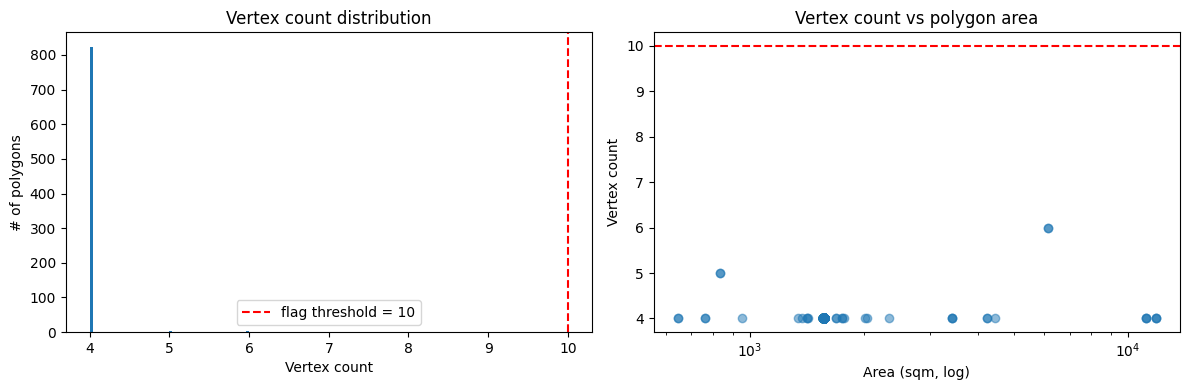


Polygons above threshold (10 vertices): 0
Worst offender: 6 vertices


In [14]:
# Histogram of vertex counts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(inv['vertex_count'], bins=50)
axes[0].axvline(VERTEX_FLAG_THRESHOLD, color='red', linestyle='--', label=f'flag threshold = {VERTEX_FLAG_THRESHOLD}')
axes[0].set_xlabel('Vertex count')
axes[0].set_ylabel('# of polygons')
axes[0].set_title('Vertex count distribution')
axes[0].legend()

# Vertex count vs area — iPad damage shows up as high-vertex small-area polygons
non_zero = inv[inv['area_sqm'] > 0]
axes[1].scatter(non_zero['area_sqm'], non_zero['vertex_count'], alpha=0.5)
axes[1].set_xscale('log')
axes[1].set_xlabel('Area (sqm, log)')
axes[1].set_ylabel('Vertex count')
axes[1].set_title('Vertex count vs polygon area')
axes[1].axhline(VERTEX_FLAG_THRESHOLD, color='red', linestyle='--')

plt.tight_layout()
plt.show()

print(f'\nPolygons above threshold ({VERTEX_FLAG_THRESHOLD} vertices): {(inv["vertex_count"] > VERTEX_FLAG_THRESHOLD).sum()}')
print(f'Worst offender: {inv["vertex_count"].max()} vertices')

In [15]:
# Top 20 offenders
top_offenders = (
    inv.sort_values('vertex_count', ascending=False)
       .head(20)
       [['file', 'placemark_name', 'project_id', 'vertex_count', 'area_sqm', 'extruded', 'max_altitude']]
)
print('Top 20 polygons by vertex count:')
top_offenders

Top 20 polygons by vertex count:


,file,placemark_name,project_id,vertex_count,area_sqm,extruded,max_altitude
169,Berkeley Housing Pipeline - 3D Skyline.kml,2556 HASTE St,None,6,6122.3,True,42.0
499,myplaces_snapshot_2026-04-25.kml,2556 HASTE St,None,6,6122.3,True,42.0
538,myplaces_snapshot_2026-04-25.kml,2660 BANCROFT Way,None,5,832.8,True,28.0
209,Berkeley Housing Pipeline - 3D Skyline.kml,2660 BANCROFT Way,None,5,832.8,True,28.0
566,myplaces_snapshot_2026-04-25.kml,1367 UNIVERSITY Ave,None,4,1565.2,True,14.0
555,myplaces_snapshot_2026-04-25.kml,2001 CENTER St,None,4,1565.2,True,30.5
548,myplaces_snapshot_2026-04-25.kml,2455 TELEGRAPH Ave,None,4,1565.3,True,28.0
549,myplaces_snapshot_2026-04-25.kml,1752 SHATTUCK Ave,None,4,950.8,True,24.5
550,myplaces_snapshot_2026-04-25.kml,2462 BANCROFT Way,None,4,1565.2,True,26.8
551,myplaces_snapshot_2026-04-25.kml,2138 KITTREDGE St,None,4,1565.2,True,28.0


## Cell 6 — Find duplicates across files

Which projects appear in multiple KML files? These are the ones where you need to pick a canonical version. Match by `project_id` if available, otherwise fall back to placemark name.

In [16]:
# Use project_id where present, fall back to name
inv['match_key'] = inv['project_id'].fillna('').replace('', None)
inv['match_key'] = inv['match_key'].fillna(inv['placemark_name'])

duplicates = (
    inv.groupby('match_key')
       .agg(
           file_count=('file', 'nunique'),
           polygon_count=('vertex_count', 'count'),
           min_vertices=('vertex_count', 'min'),
           max_vertices=('vertex_count', 'max'),
           files=('file', lambda s: '; '.join(sorted(set(s)))),
       )
       .query('file_count > 1')
       .sort_values('max_vertices', ascending=False)
)

print(f'Projects appearing in multiple files: {len(duplicates)}')
print('(For each, you\'ll need to pick which version is canonical)')
duplicates.head(20)

Projects appearing in multiple files: 163
(For each, you'll need to pick which version is canonical)


,file_count,polygon_count,min_vertices,max_vertices,files
match_key,,,,,
2556 HASTE St,4,5,4,6,Berkeley Housing Pipeline - 3D Skyline.kml; be...
2660 BANCROFT Way,4,5,4,5,Berkeley Housing Pipeline - 3D Skyline.kml; be...
0 LE ROY Ave,4,5,4,4,Berkeley Housing Pipeline - 3D Skyline.kml; be...
2462 BANCROFT Way,4,5,4,4,Berkeley Housing Pipeline - 3D Skyline.kml; be...
2428 MILVIA St,4,5,4,4,Berkeley Housing Pipeline - 3D Skyline.kml; be...
2437 WARRING St,4,5,4,4,Berkeley Housing Pipeline - 3D Skyline.kml; be...
2441 LE CONTE Ave,4,5,4,4,Berkeley Housing Pipeline - 3D Skyline.kml; be...
2442 HASTE St,4,5,4,4,Berkeley Housing Pipeline - 3D Skyline.kml; be...
2449 DWIGHT Way,4,5,4,4,Berkeley Housing Pipeline - 3D Skyline.kml; be...


## Cell 7 — Save reports

Three CSVs written to `OUTPUT_DIR`:
- `polygon_inventory.csv` — every polygon, every file
- `top_offenders.csv` — polygons above the vertex threshold
- `duplicates.csv` — projects in multiple files

In [17]:
ts = datetime.now().strftime('%Y-%m-%d')

inv_path = OUTPUT_DIR / f'polygon_inventory_{ts}.csv'
inv.to_csv(inv_path, index=False)
print(f'Wrote {inv_path}')

flagged = inv[inv['vertex_count'] > VERTEX_FLAG_THRESHOLD].sort_values('vertex_count', ascending=False)
flagged_path = OUTPUT_DIR / f'top_offenders_{ts}.csv'
flagged.to_csv(flagged_path, index=False)
print(f'Wrote {flagged_path}  ({len(flagged)} polygons above threshold)')

dup_path = OUTPUT_DIR / f'duplicates_{ts}.csv'
duplicates.to_csv(dup_path)
print(f'Wrote {dup_path}  ({len(duplicates)} projects in multiple files)')

Wrote /Users/johngage/berkeley-data/notebooks/06_polygon_cleanup/reports/polygon_inventory_2026-04-25.csv
Wrote /Users/johngage/berkeley-data/notebooks/06_polygon_cleanup/reports/top_offenders_2026-04-25.csv  (0 polygons above threshold)
Wrote /Users/johngage/berkeley-data/notebooks/06_polygon_cleanup/reports/duplicates_2026-04-25.csv  (163 projects in multiple files)


---

## What to look at next

After running the notebook, the questions to answer are:

1. **Is the histogram bimodal?** If yes, the threshold separates clean from damaged cleanly. If not, we need a different signal (vertex density, or comparing against the older KMLs specifically).
2. **How many top offenders?** If <10, hand-fix in Earth Pro. If >10, automation is worth building.
3. **Do any placemarks have `project_id` in ExtendedData?** If yes, the round-trip to the DB is straightforward. If no, your Python exporter needs to start emitting it before any cleanup pass.
4. **Which KML files have the cleanest versions?** Sort the duplicates report by `min_vertices` to find which file most often holds the lowest-vertex (presumably pre-iPad) version of each project.

Send me the three CSVs (or just the top-offenders summary) and we can decide on the next pass — whether that's restoring from older KMLs, snapping to parcel data, or hand-editing in Earth Pro.